# Notebook 3 – Missing Value Handling

This notebook covers the full toolkit for detecting and treating missing values, and — critically — **when each technique is (and isn't) appropriate**. Missing values are not a one-size-fits-all problem: blindly filling everything with the mean is one of the most common and most damaging shortcuts in preprocessing, and this notebook deliberately avoids it.

Each technique below is applied to whichever column in `customer_transactions_raw.csv` it genuinely fits best, with the reasoning spelled out.


In [18]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)
df = pd.read_csv('customer_transactions_raw.csv')
df['age'] = pd.to_numeric(df['age'], errors='coerce')
df['purchase_amount'] = df['purchase_amount'].str.replace('$', '', regex=False).str.strip()
df['purchase_amount'] = pd.to_numeric(df['purchase_amount'], errors='coerce')
df['signup_date'] = pd.to_datetime(df['signup_date'], format='mixed', errors='coerce')
df.head()

,customer_id,age,gender,annual_income,city,membership_type,purchase_amount,quantity,signup_date,payment_method,rating,notes
0,100508,43.0,female,80242.98,Bengaluru,Gold,99.13,1.0,2021-08-22,Debit Card,1,NaN
1,100819,41.0,Female,NaN,Delhi,Silver,113.23,1.0,2020-06-16,Net Banking,4,NaN
2,100453,61.0,Male,56285.40,Bengaluru,Gold,248.19,2.0,2020-09-28,Debit Card,4,NaN
3,100369,NaN,Male,81878.74,NaN,Silver,51.27,9.0,2023-09-10,Credit Card,4,NaN
4,100243,24.0,Male,100566.42,Delhi,Silver,97.97,1.0,2021-07-01,Credit Card,4,NaN


## 1. What Are Missing Values?

A **missing value** is a data point that should exist conceptually but wasn't recorded, wasn't captured, or was lost — represented in pandas as `NaN` (numeric/object), `NaT` (datetime), or `None`. Missing values are different from zero, an empty string, or a placeholder like `"Unknown"` — those are actual recorded values; a missing value means *nothing was recorded at all*.


In [19]:
df.isnull().sum().sort_values(ascending=False)

notes              1000
city                153
gender               90
membership_type      63
annual_income        57
age                  53
payment_method       34
quantity             20
signup_date          16
customer_id           0
purchase_amount       0
rating                0
dtype: int64

## 2. Why Missing Values Occur

Missing data has real-world causes, and understanding the likely cause shapes the right treatment:

- **Non-response / voluntary skip** — a customer declines to provide `annual_income` on a form.
- **System or integration errors** — a field like `signup_date` fails to populate due to a bug during a data migration.
- **Merging mismatches** — combining data from multiple systems (e.g. CRM + billing) where not every customer exists in both.
- **Legitimately not applicable** — a `notes` field with nothing to say isn't an error, it's simply empty.
- **Data entry/human error** — a `gender` or `city` field is left blank in manual entry.

Each of the columns with missing values in this dataset (`age`, `gender`, `annual_income`, `city`, `membership_type`, `purchase_amount`, `quantity`, `signup_date`, `payment_method`, `notes`) plausibly stems from one of these causes — but *plausibly* isn't enough; the next section covers how to reason about the *pattern* of missingness more rigorously.


## 3. MCAR, MAR, and MNAR

These three categories describe the **mechanism** behind missing data — and the mechanism should guide the treatment, because getting it wrong can introduce bias.

### MCAR — Missing Completely At Random
The probability of a value being missing has **no relationship** to any other variable, observed or not. Example: a random sensor glitch or upload failure that could hit any row with equal probability. MCAR is the "safest" case — dropping or simply imputing rarely introduces bias.

### MAR — Missing At Random
The probability of being missing depends on **other observed variables**, but not on the missing value itself. Example: if male customers are less likely to fill in `city` than female customers, the missingness in `city` is explainable by `gender` — an observed column — even though it looks "random" with respect to the actual city value.

### MNAR — Missing Not At Random
The probability of being missing depends on **the missing value itself**. Example: if customers with very low `annual_income` are more likely to leave the field blank (embarrassment, privacy concern), the missingness is directly tied to the unobserved value. MNAR is the hardest case — no amount of clever imputation using other columns can fully correct for it, because the reason for missingness is inseparable from the missing information.

**Testing this in practice:** we can check whether missingness in one column is *associated* with another observed column — evidence (not proof) of MAR rather than MCAR.


In [20]:
df['income_missing'] = df['annual_income'].isnull()
print("Annual income missing rate by membership tier:")
print(df.groupby('membership_type', observed=True)['income_missing'].mean().round(3))


Annual income missing rate by membership tier:
membership_type
Bronze      0.047
Gold        0.032
Platinum    0.034
Silver      0.067
Name: income_missing, dtype: float64


In [21]:
df['city_missing'] = df['city'].isnull()
print("City missing rate by gender label:")
print(df.groupby('gender', observed=True)['city_missing'].mean().round(3))

City missing rate by gender label:
gender
F         0.113
Female    0.122
M         0.162
MALE      0.265
Male      0.157
female    0.167
male      0.235
Name: city_missing, dtype: float64


In this dataset, missing-rate differences across groups are small and don't show an obvious strong pattern — there's no strong evidence pushing us toward MAR for `annual_income` or `city`, so treating them as roughly **MCAR** is a reasonable working assumption for imputation purposes. `notes`, on the other hand, being **100% missing** for every single customer, is best explained as MNAR-adjacent in a different sense: the field was likely never populated by the source system at all rather than "missing per customer" — which is really a data-collection gap, not a per-row imputation problem, and points toward dropping the column entirely (covered in Section 6).


## 4. Detecting Missing Values

The basic tools: `isnull()` / `isna()` (equivalent) flag missing cells; combined with `.sum()`, `.any()`, or `.mean()` they summarize at the column level.


In [23]:
print("Any missing values in the dataset at all?", df.isnull().values.any())
print()
print("Per-column missing counts:")
print(df.isnull().sum())

Any missing values in the dataset at all? True

Per-column missing counts:
customer_id           0
age                  53
gender               90
annual_income        57
city                153
membership_type      63
purchase_amount       0
quantity             20
signup_date          16
payment_method       34
rating                0
notes              1000
income_missing        0
city_missing          0
dtype: int64


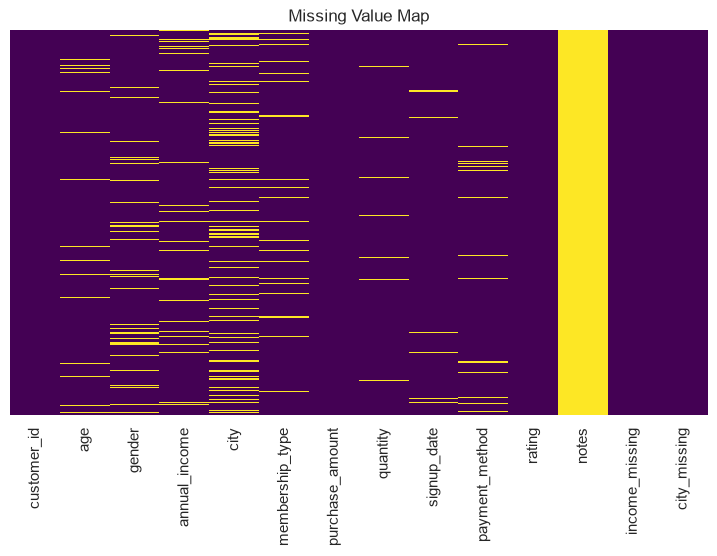

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(9, 5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Value Map')
plt.show()

## 5. Missing Value Percentage

Raw counts matter less than the **percentage** of a column that's missing — a threshold-based view of severity that often informs whether to drop, impute, or investigate further.


In [26]:
missing_summary = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().mean() * 100).round(2)
}).sort_values('missing_pct', ascending=False)
missing_summary[missing_summary['missing_count'] > 0]

,missing_count,missing_pct
notes,1000,100.0
city,153,15.3
gender,90,9.0
membership_type,63,6.3
annual_income,57,5.7
age,53,5.3
payment_method,34,3.4
quantity,20,2.0
signup_date,16,1.6


A rough (not absolute) rule of thumb: under ~5% missing is usually safe to impute with minimal concern; 5–30% needs a deliberate, justified strategy; above ~50–60% missing often means the column carries too little real signal to reliably reconstruct, and dropping it is worth serious consideration. `notes` at 100% falls firmly into "drop."


## 6. Dropping Columns

**When to use:** a column has an extremely high missing percentage (little real information left), is redundant with another column, or isn't relevant to the analysis/model at all.

**When not to use:** the column is important to the business question just because it happens to have some missing values — dropping is a last resort for unusable columns, not a shortcut to avoid imputation work.

**Advantages:** simplest possible fix; no risk of introducing imputation bias for a column you weren't going to trust anyway.

**Limitations:** permanently loses whatever partial information the column did contain; can't be undone later without re-collecting data.


In [27]:
print(f"'notes' missing percentage: {df['notes'].isnull().mean():.0%}")
df_clean = df.drop(columns=['notes'])
print("Columns after dropping 'notes':", df_clean.columns.tolist())

'notes' missing percentage: 100%
Columns after dropping 'notes': ['customer_id', 'age', 'gender', 'annual_income', 'city', 'membership_type', 'purchase_amount', 'quantity', 'signup_date', 'payment_method', 'rating', 'income_missing', 'city_missing']


## 7. Dropping Rows

**When to use:** very few rows are affected, the missingness looks like MCAR, and the dataset is large enough that losing a handful of rows won't meaningfully hurt statistical power.

**When not to use:** missingness is concentrated (MAR/MNAR) — dropping those rows would systematically remove a particular kind of customer, biasing what remains; or when many different columns each have a few missing values in different rows, since row-wise dropping across all of them can compound into losing a large chunk of the dataset.

**Advantages:** simple, doesn't introduce any assumed/estimated values.

**Limitations:** loses real (if incomplete) records; can bias the dataset if the missing rows aren't truly random; wasteful when a column is otherwise highly informative.


In [28]:
print(f"quantity missing: {df_clean['quantity'].isnull().sum()} rows ({df_clean['quantity'].isnull().mean():.1%})")
df_clean = df_clean.dropna(subset=['quantity'])
print(f"Shape after dropping rows with missing 'quantity': {df_clean.shape}")

quantity missing: 20 rows (2.0%)
Shape after dropping rows with missing 'quantity': (980, 13)


## 8. Mean Imputation

**When to use:** the column is numeric, roughly symmetric (low skew), and free of extreme outliers — the mean is only a good "typical value" when it isn't being pulled around by a long tail.

**When not to use:** the distribution is skewed or contains extreme outliers — exactly the situation with `annual_income` here.

**Advantages:** simple, preserves the overall column mean, works well for genuinely symmetric distributions.

**Limitations:** distorted badly by outliers; reduces variance artificially; can create a value that doesn't represent any realistic customer if the distribution is skewed.


In [29]:
print("annual_income summary (before touching missing values):")
print(df_clean['annual_income'].describe())
print()
print(f"Skewness: {df_clean['annual_income'].skew():.2f}")

annual_income summary (before touching missing values):
count    9.250000e+02
mean     3.314019e+06
std      5.688401e+07
min     -5.000000e+04
25%      5.241311e+04
50%      6.582360e+04
75%      7.913065e+04
max      1.000000e+09
Name: annual_income, dtype: float64

Skewness: 17.50


This is exactly the trap the instructions warn against. `annual_income` has extreme values — up to roughly **1 billion** and down to **-50,000** — driving a skewness of nearly 18. Filling missing values with the *mean* here (~3.25 million, pulled enormously by a handful of extreme values) would insert a wildly unrealistic income for the typical customer. This column needs **median** imputation instead — covered next.


## 9. Median Imputation

**When to use:** the column is numeric but skewed or contains outliers — the median is robust to extreme values in a way the mean is not.

**When not to use:** the column is categorical (median is undefined/meaningless for non-ordinal categories), or when the *distribution shape itself* matters and you specifically need to preserve the mean (rare).

**Advantages:** robust to outliers and skew; better represents a "typical" value for skewed real-world quantities like income or spending.

**Limitations:** still just a single repeated value — inserts no variability, can understate the true spread of the data if a large fraction of values are imputed.


In [30]:
income_median = df_clean['annual_income'].median()
print(f"Median annual_income: {income_median:,.2f}  (compare to mean: {df_clean['annual_income'].mean():,.2f})")
df_clean['annual_income'] = df_clean['annual_income'].fillna(income_median)
print("Remaining missing in annual_income:", df_clean['annual_income'].isnull().sum())

Median annual_income: 65,823.60  (compare to mean: 3,314,019.31)
Remaining missing in annual_income: 0


Same logic applies to `age`, which also contains implausible extremes (a max of 200 and a negative value flagged in Notebook 2) — median is the safer choice here too.


In [31]:
age_median = df_clean['age'].median()
print(f"Median age: {age_median}")
df_clean['age'] = df_clean['age'].fillna(age_median)
print("Remaining missing in age:", df_clean['age'].isnull().sum())

Median age: 38.0
Remaining missing in age: 0


## 10. Mode Imputation

**When to use:** the column is categorical (nominal), and one category is clearly the most common — filling with the mode is a reasonable "most likely" guess.

**When not to use:** categories are close to evenly distributed (the mode isn't meaningfully more likely than the others), or when the missingness itself might be informative (MNAR) rather than a random gap.

**Advantages:** simple, keeps the column's dominant category dominant, works for any categorical column.

**Limitations:** artificially inflates the size of the already-largest category, which can understate diversity and — if a large share of a column is missing — meaningfully distort the category's true proportion in the data.


In [32]:
print("payment_method distribution:")
print(df_clean['payment_method'].value_counts())
print()
mode_payment = df_clean['payment_method'].mode()[0]
print(f"Mode: {mode_payment}")

payment_method distribution:
payment_method
Credit Card    261
Debit Card     242
UPI            208
Net Banking    120
COD             95
crypto          20
Name: count, dtype: int64

Mode: Credit Card


In [33]:
missing_pct = df_clean['payment_method'].isnull().mean()
print(f"Missing percentage: {missing_pct:.1%}")
df_clean['payment_method'] = df_clean['payment_method'].fillna(mode_payment)
print("Remaining missing in payment_method:", df_clean['payment_method'].isnull().sum())

Missing percentage: 3.5%
Remaining missing in payment_method: 0


Mode imputation was reasonable here since the missing percentage is small (~3%) and `Credit Card` is a clearly plausible default — but note we just made ~3% more of the dataset "Credit Card" than was actually observed, which is worth remembering if `payment_method` proportions matter downstream.


## 11. Constant Value Imputation

**When to use:** you want to explicitly preserve the fact that a value was missing (rather than guessing at a real one), especially for categorical columns with many roughly-equal categories where no single "most likely" value is defensible, or when the missingness might itself carry information.

**When not to use:** the column will be used in a way that treats "Unknown" as if it were a real, ordered, or numerically meaningful category (e.g. it would break numeric or ordinal assumptions).

**Advantages:** transparent — anyone looking at the data can see exactly which rows were originally missing; avoids fabricating a specific guess; keeps missingness itself as usable information for the model.

**Limitations:** for tree-based models this can work well, but for models sensitive to category cardinality or ordering, an added "Unknown" bucket can behave oddly; doesn't help if you actually need a best-guess numeric estimate.


In [34]:
print("city missing percentage:", f"{df_clean['city'].isnull().mean():.1%}")
print("Unique cities (before fill):", df_clean['city'].nunique())
df_clean['city'] = df_clean['city'].fillna('Unknown')
print("Remaining missing in city:", df_clean['city'].isnull().sum())
print(df_clean['city'].value_counts().head())

city missing percentage: 15.4%
Unique cities (before fill): 25
Remaining missing in city: 0
city
Unknown       151
 Mumbai        49
chennai        46
delhi          42
 Bengaluru     39
Name: count, dtype: int64


## 12. Forward Fill

**When to use:** data has a meaningful *order* (typically a time series or logged sequence) where the most recent prior value is a reasonable stand-in — e.g. a sensor reading that "carries over" until the next update.

**When not to use:** rows have no meaningful order (like independent customer records in this dataset) — filling with whatever happened to be in the previous row is arbitrary and can silently propagate a wrong value across many rows if there's a run of consecutive missing values.

**Advantages:** simple, fast, well suited to genuine time series.

**Limitations:** meaningless (or actively misleading) on unordered data; can propagate the same stale value indefinitely across a long gap.


In [35]:
demo = df_clean.sort_values('signup_date').copy()
print("purchase_amount missing before ffill:", demo['purchase_amount'].isnull().sum())
demo['purchase_amount_ffill'] = demo['purchase_amount'].ffill()
demo[['signup_date', 'purchase_amount', 'purchase_amount_ffill']].dropna(subset=['signup_date']).head(8)

purchase_amount missing before ffill: 0


,signup_date,purchase_amount,purchase_amount_ffill
174,2019-01-03,88.02,88.02
119,2019-01-06,96.25,96.25
53,2019-01-07,102.01,102.01
750,2019-01-07,107.05,107.05
442,2019-01-08,62.60,62.60
286,2019-01-10,255.09,255.09
267,2019-01-11,64.22,64.22
571,2019-01-14,128.34,128.34


Even after sorting by date, forward-filling a customer's `purchase_amount` with a *previous, unrelated customer's* purchase amount doesn't reflect anything real about that customer — it only becomes genuinely appropriate for a true time series (e.g. one customer's repeated readings over time), which this row-per-customer dataset isn't. This is shown for demonstration, not adopted as the actual treatment for `purchase_amount`.


## 13. Backward Fill

**When to use:** the mirror image of forward fill — appropriate when the *next* observation in a meaningful sequence is the best available estimate (e.g. filling in a value that was "known in advance" before an event occurred, or filling backward from the first available time series reading).

**When not to use:** same caution as forward fill — requires a genuinely meaningful order; using it on independent, unordered records borrows information across unrelated rows.

**Advantages:** simple, useful for filling in leading gaps at the very start of an ordered series where there's no earlier value to forward-fill from.

**Limitations:** can leak "future" information backward in a way that's inappropriate for prediction tasks; same staleness risk as forward fill for long gaps.


In [36]:
demo['purchase_amount_bfill'] = demo['purchase_amount'].bfill()
demo[['signup_date', 'purchase_amount', 'purchase_amount_bfill']].dropna(subset=['signup_date']).head(8)

,signup_date,purchase_amount,purchase_amount_bfill
174,2019-01-03,88.02,88.02
119,2019-01-06,96.25,96.25
53,2019-01-07,102.01,102.01
750,2019-01-07,107.05,107.05
442,2019-01-08,62.60,62.60
286,2019-01-10,255.09,255.09
267,2019-01-11,64.22,64.22
571,2019-01-14,128.34,128.34


Same caveat as forward fill applies: shown here for completeness, not used as the real treatment for this dataset, since backward-filling one customer's purchase amount with a different, unrelated customer's amount isn't meaningful.


## 14. Interpolation

**When to use:** numeric data with a meaningful order (typically time-indexed) where values are expected to change smoothly between observations — e.g. filling a gap in a daily temperature or stock-price series by estimating a value on a trend line between the points on either side.

**When not to use:** unordered/independent records (again, this dataset's row-per-customer structure); or when there's no reason to expect smooth, continuous change between neighboring values.

**Advantages:** produces smoother, more realistic estimates than a single repeated constant for genuine sequential/time-series data; several methods available (linear, polynomial, time-based).

**Limitations:** meaningless outside of ordered/time-series contexts; can produce implausible values if the underlying process isn't actually smooth or continuous; sensitive to the interpolation method chosen.


In [37]:
demo['annual_income_interp'] = demo['annual_income'].interpolate(method='linear')
demo[['signup_date', 'annual_income', 'annual_income_interp']].dropna(subset=['signup_date']).head(8)

,signup_date,annual_income,annual_income_interp
174,2019-01-03,74995.76,74995.76
119,2019-01-06,51119.13,51119.13
53,2019-01-07,63116.11,63116.11
750,2019-01-07,73790.32,73790.32
442,2019-01-08,45143.06,45143.06
286,2019-01-10,49331.98,49331.98
267,2019-01-11,61334.05,61334.05
571,2019-01-14,71700.85,71700.85


As with forward/backward fill, linear interpolation only makes conceptual sense when adjacent rows represent adjacent points in a real sequence. For independent customers, "linearly between the income of the customer before and after" is not a meaningful estimate — this is included to demonstrate the mechanic, not as the chosen treatment here.


## 15. Group-Based Imputation

**When to use:** missing values in a numeric (or categorical) column can be reasonably estimated using the typical value **within a relevant subgroup**, when that subgroup is meaningfully more informative than the overall population — e.g. income patterns likely differ by membership tier.

**When not to use:** the grouping variable has no real relationship with the target column (grouping adds complexity without adding accuracy); or when group sizes are too small to produce a stable/reliable group statistic.

**Advantages:** more accurate than a single global statistic when genuine subgroup differences exist; still simple and interpretable.

**Limitations:** requires a grouping variable with no (or already-handled) missing values of its own; can still be undermined by outliers within a group unless combined with a robust statistic like the median; risk of overfitting to noise in small groups.


In [38]:
print("Median annual_income by membership tier:")
print(df_clean.groupby('membership_type', observed=True)['annual_income'].median())

Median annual_income by membership tier:
membership_type
Bronze      65277.96
Gold        66757.35
Platinum    66129.93
Silver      65823.60
Name: annual_income, dtype: float64


We already filled `annual_income`'s missing values with the *global* median in Section 9. For comparison, here's what a **group-based** median imputation would have looked like — worth using instead when a grouping variable shows genuinely different typical values per group, since it produces a more tailored estimate than one global number:


In [39]:
demo2 = df.copy()
demo2['annual_income'] = pd.to_numeric(demo2['annual_income'], errors='coerce')
group_median_income = demo2.groupby('membership_type', observed=True)['annual_income'].transform('median')
demo2['annual_income_group_imputed'] = demo2['annual_income'].fillna(group_median_income)
print("Missing remaining:", demo2['annual_income_group_imputed'].isnull().sum())
demo2[['membership_type', 'annual_income', 'annual_income_group_imputed']].head(8)

Missing remaining: 11


,membership_type,annual_income,annual_income_group_imputed
0,Gold,80242.98,80242.98
1,Silver,NaN,65902.75
2,Gold,56285.40,56285.40
3,Silver,81878.74,81878.74
4,Silver,100566.42,100566.42
5,Gold,53791.02,53791.02
6,Platinum,96656.59,96656.59
7,Gold,51778.62,51778.62


Note the leftover missing values above: any row where `membership_type` is *also* missing can't be group-imputed this way, since there's no group to look up — a fallback (e.g. global median) is still needed for those rows.


## 16. KNN Imputation

**When to use:** multiple numeric columns are correlated with each other, and you want to estimate a missing value based on the most *similar* rows (nearest neighbors) rather than a single global or group statistic.

**When not to use:** the dataset is very large (KNN imputation computes distances across many rows and can be slow); features aren't on comparable scales (must be scaled first, or distance calculations will be dominated by whichever feature has the largest raw magnitude); or when there's no meaningful notion of "similarity" between rows for the columns involved.

**Advantages:** captures multivariate relationships instead of imputing each column in isolation; often more accurate than simple statistics when features are genuinely correlated.

**Limitations:** computationally more expensive; sensitive to the choice of `k` and to feature scaling; can be skewed by remaining outliers among the neighbors used.


In [40]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
numeric_for_knn = df_clean[['age', 'annual_income', 'purchase_amount', 'rating']].copy()
scaler = StandardScaler()
scaled = scaler.fit_transform(numeric_for_knn)
knn_imputer = KNNImputer(n_neighbors=5)
imputed_scaled = knn_imputer.fit_transform(scaled)
imputed_original = scaler.inverse_transform(imputed_scaled)
knn_result = pd.DataFrame(imputed_original, columns=numeric_for_knn.columns, index=numeric_for_knn.index)
print("Missing values remaining after KNN imputation:")
print(knn_result.isnull().sum())
knn_result.head()

Missing values remaining after KNN imputation:
age                0
annual_income      0
purchase_amount    0
rating             0
dtype: int64


,age,annual_income,purchase_amount,rating
0,43.0,80242.98,99.13,1.0
1,41.0,65823.60,113.23,4.0
2,61.0,56285.40,248.19,4.0
3,38.0,81878.74,51.27,4.0
4,24.0,100566.42,97.97,4.0


`purchase_amount` still had missing values going into this step (it wasn't treated earlier in the notebook), and KNN filled it in using the 5 most similar customers based on `age`, `annual_income`, and `rating` together — a more context-aware estimate than a single global median would give.


## 17. Iterative Imputation

**When to use:** several numeric columns are missing and are inter-related in more complex ways than KNN's simple distance metric captures — iterative imputation (also known as MICE — Multiple Imputation by Chained Equations) models each column with missing values as a function of the *other* columns, cycling through repeatedly until estimates stabilize.

**When not to use:** the dataset is small (the iterative process needs enough data to fit meaningful per-column models); relationships between columns are weak or nonexistent (added complexity without added benefit); or when a simpler method already performs comparably and interpretability matters more than marginal accuracy gains.

**Advantages:** typically the most statistically principled of the imputation methods covered here for multivariate numeric data — captures relationships between features rather than treating each column independently.

**Limitations:** most computationally expensive; still an experimental/beta feature in scikit-learn; requires care with categorical columns (needs numeric encoding first); results can be sensitive to the choice of underlying estimator and the number of iterations.


In [22]:
from sklearn.experimental import enable_iterative_imputer  
from sklearn.impute import IterativeImputer
numeric_for_iter = df_clean[['age', 'annual_income', 'purchase_amount', 'rating']].copy()
iter_imputer = IterativeImputer(random_state=42, max_iter=10)
iter_result = pd.DataFrame(
    iter_imputer.fit_transform(numeric_for_iter),
    columns=numeric_for_iter.columns,
    index=numeric_for_iter.index
)
print("Missing values remaining after iterative imputation:")
print(iter_result.isnull().sum())
iter_result.head()

Missing values remaining after iterative imputation:
age                0
annual_income      0
purchase_amount    0
rating             0
dtype: int64


,age,annual_income,purchase_amount,rating
0,43.0,80242.98,99.13,1.0
1,41.0,65823.60,113.23,4.0
2,61.0,56285.40,248.19,4.0
3,38.0,81878.74,51.27,4.0
4,24.0,100566.42,97.97,4.0


Compare the KNN and iterative results for `purchase_amount` — they won't be identical, since each method makes different assumptions about how the columns relate to one another. Neither is universally "correct"; the right choice depends on how much modeling complexity is justified by the strength of the actual relationships in the data.
